In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from anonymeter.evaluators import SinglingOutEvaluator
from anonymeter.evaluators import LinkabilityEvaluator
from anonymeter.evaluators import InferenceEvaluator

# # create a file handler
# file_handler = logging.FileHandler("anonymeter.log")

# # set the logging level for the file handler
# file_handler.setLevel(logging.DEBUG)

# # add the file handler to the logger
# logger = logging.getLogger("anonymeter")
# logger.addHandler(file_handler)
# logger.setLevel(logging.DEBUG)

In [2]:
ori = pd.read_csv("ori_214000_float.csv")
syn = pd.read_csv("ori_214000_ver_syn_float.csv")
control = pd.read_csv("control_float.csv")

In [3]:
evaluator = SinglingOutEvaluator(ori=ori, 
                                 syn=syn, 
                                 control=control,
                                 n_attacks=500)

try:
    evaluator.evaluate(mode='multivariate') # mode = "univariate" or "multivariate"
    risk = evaluator.risk()
    print(risk)

except RuntimeError as ex: 
    print(f"Singling out evaluation failed with {ex}. Please re-run this cell."
          "For more stable results increase `n_attacks`. Note that this will "
          "make the evaluation slower.")

PrivacyRisk(value=0.9958025083485815, ci=(0.9916034244512535, 1.0))


In [4]:
evaluator.queries()[:3]

["age<= 19 & occupation== 'Admin-clerical' & id<= 80736",
 "occupation== 'Mechanic-and-repair-workers' & mobility>= 0.982 & health<= 2",
 "occupation== 'Healthcare-practitioners' & education== 'Masters' & mobility<= 0.442"]

In [5]:
res = evaluator.results()

print("Successs rate of main attack:", res.attack_rate)
print("Successs rate of baseline attack:", res.baseline_rate)
print("Successs rate of control attack:", res.control_rate)

Successs rate of main attack: SuccessRate(value=0.9961878297692239, error=0.00381217023077612)
Successs rate of baseline attack: SuccessRate(value=0.09511073090831332, error=0.025428007227861246)
Successs rate of control attack: SuccessRate(value=0.09179801954154719, error=0.025017780307798637)


In [6]:
aux_cols = [
    ['id','age' , 'education', 'occupation'],
    ['income', 'mobility','health','life_quality']
]

evaluator = LinkabilityEvaluator(ori=ori, 
                                 syn=syn, 
                                 control=control,
                                 n_attacks=5000,
                                 aux_cols=aux_cols,
                                 n_neighbors=10)

evaluator.evaluate(n_jobs=-1)  # n_jobs follow joblib convention. -1 = all cores, -2 = all execept one
evaluator.risk()

PrivacyRisk(value=0.9996156943028238, ci=(0.9992313884591613, 1.0))

In [7]:
res = evaluator.results()

print("Successs rate of main attack:", res.attack_rate)
print("Successs rate of baseline attack:", res.baseline_rate)
print("Successs rate of control attack:", res.control_rate)

Successs rate of main attack: SuccessRate(value=0.9996161490274714, error=0.00038385097252856216)
Successs rate of baseline attack: SuccessRate(value=0.001383083270583505, error=0.0009558697794747054)
Successs rate of control attack: SuccessRate(value=0.0011832368109725164, error=0.0008720898348709537)


In [8]:
print(evaluator.risk(n_neighbors=8))

PrivacyRisk(value=0.9996157711805577, ci=(0.9992315422442082, 1.0))


In [9]:
columns = ori.columns
results = []

for secret in columns:
    
    aux_cols = [col for col in columns if col != secret]
    
    evaluator = InferenceEvaluator(ori=ori, 
                                   syn=syn, 
                                   control=control,
                                   aux_cols=aux_cols,
                                   secret=secret,
                                   n_attacks=1000)
    evaluator.evaluate(n_jobs=-2)
    results.append((secret, evaluator.results()))

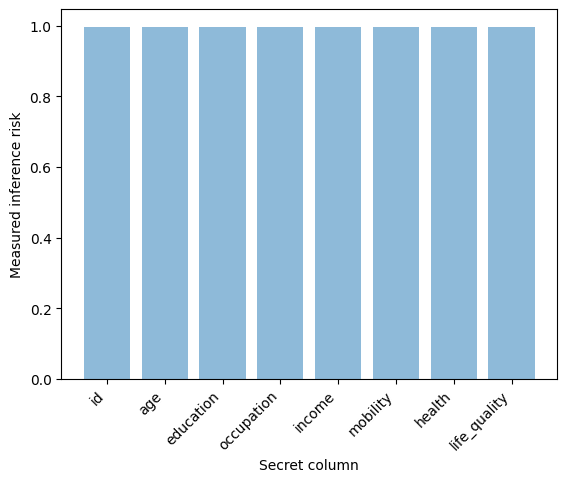

In [10]:
fig, ax = plt.subplots()

risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

ax.bar(x=columns, height=risks, alpha=0.5, ecolor='black', capsize=10)

plt.xticks(rotation=45, ha='right')
# ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_ylabel("Measured inference risk")
_ = ax.set_xlabel("Secret column")